In [44]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [45]:
df = pd.read_parquet('../data/clean/2009-01-02-SPY.P-trade.parquet')
df['sign'] = np.sign(df['trade-price']-df['mid-price'])
df.head()
#print(df.shape)

,bid-price,bid-volume,ask-price,ask-volume,trade-price,trade-volume,mid-price,weighted-price,spread,relative-spread,sign
xltime,,,,,,,,,,,
2009-01-02 09:30:00.117999800-05:00,90.44,86.500000,90.46,68.000000,90.45,156.0,90.45,90.45,0.02,0.0002,0.0
2009-01-02 09:30:00.127999624-05:00,90.44,66.666667,90.45,6.666667,90.45,156.0,90.44,90.44,0.01,0.0001,1.0
2009-01-02 09:30:00.150999779-05:00,90.44,21.000000,90.45,28.000000,90.45,156.0,90.44,90.45,0.01,0.0001,1.0
2009-01-02 09:30:00.160000050-05:00,90.44,21.000000,90.45,30.000000,90.45,156.0,90.44,90.45,0.01,0.0001,1.0
2009-01-02 09:30:00.161999769-05:00,90.44,18.000000,90.45,33.000000,90.45,156.0,90.44,90.45,0.01,0.0001,1.0


In [46]:
def response(tau):
    midprice = df['mid-price'].values
    sign = df['sign'].values[:-tau]

    midprice_pres = midprice[:-tau]
    midprice_shifted = midprice[tau:]
    diff_midprice = midprice_shifted - midprice_pres
    vec = diff_midprice * sign
    mean = np.mean(vec)
    return mean

In [47]:
resp = []
tau_vec = np.linspace(1, 1000, 10000, dtype=int)
for tau in tau_vec:
    resp.append(response(tau))

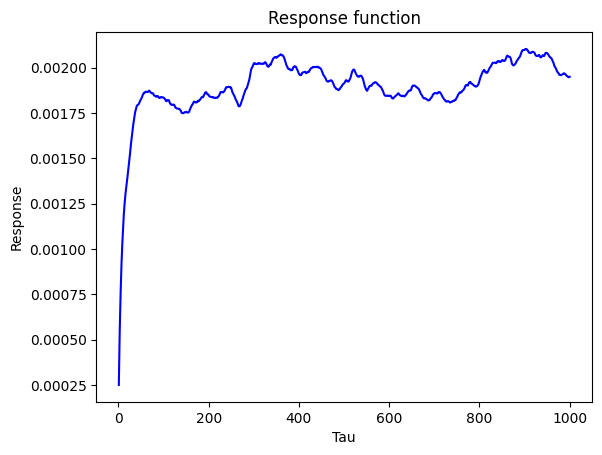

In [48]:
plt.plot(tau_vec, resp, color='blue')
plt.xlabel('Tau')
plt.ylabel('Response')
plt.title('Response function')
plt.show()